Query point: [5.9 2.9]
True class of query point: 1
The query point is: [5.9 2.9]

The nearest neighbors of the query point are:
 [[6.  2.9]
 [5.9 3. ]
 [6.1 2.9]
 [5.7 2.9]
 [6.1 2.8]]

The classes of the nearest neighbors are: [1 2 1 1 1]

Predicted class for query point: 1


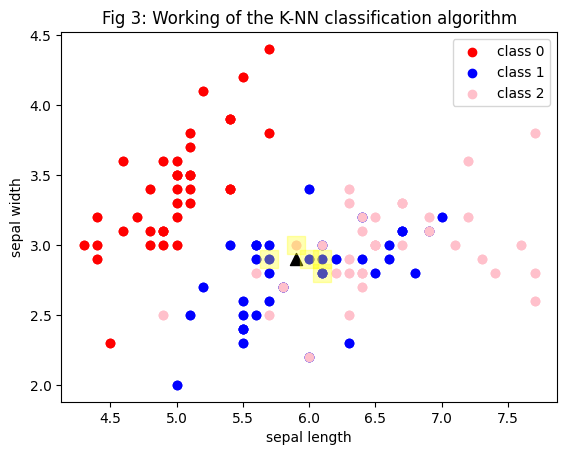

Evaluating K-NN classifier:
test misclassification percentage = 18.666666666666664%


In [12]:
from __future__ import print_function

import numpy as np
from sklearn import datasets, neighbors, linear_model, tree
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_iris, fetch_olivetti_faces
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from time import time
%matplotlib inline

iris = load_iris()
x = iris.data[:,:2]
y = iris.target

number_of_samples=len(y)

#splitting into training and test data
random_indices=np.random.permutation(number_of_samples)

#training data
num_training_samples = int(number_of_samples*0.75)
x_train = x[random_indices[:num_training_samples]]
y_train = y[random_indices[:num_training_samples]]

#testing data
x_test = x[random_indices[:number_of_samples]]
y_test = y[random_indices[:number_of_samples]]

#visualise the data
X_class0 = np.array([x_train[i] for i in range(len(x_train)) if y_train[i]==0]) #Picking only the first two classes
Y_class0 = np.zeros((X_class0.shape[0]),dtype=int)
X_class1 = np.array([x_train[i] for i in range(len(x_train)) if y_train[i]==1])
Y_class1 = np.ones((X_class1.shape[0]),dtype=int)
X_class2 = np.array([x_train[i] for i in range(len(x_train)) if y_train[i]==2])
Y_class2 = np.full((X_class2.shape[0]),fill_value=2,dtype=int)

plt.scatter(X_class0[:,0],X_class0[:,1],color='red')
plt.scatter(X_class1[:,0], X_class1[:,1], color='blue')
plt.scatter(X_class2[:,0], X_class2[:,1], color='pink')
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.legend(['class 0','class 1', 'class 2'])
plt.title('Visualization of training data')
plt.show

#K nearest algorithm 
model = neighbors.KNeighborsClassifier(n_neighbors = 5) # K = 5
model.fit(x_train, y_train)

query_point = np.array([5.9,2.9])
true_class_of_query_point = 1
predicted_class_for_query_point = model.predict([query_point])
print("Query point: {}".format(query_point))
print("True class of query point: {}".format(true_class_of_query_point))

query_point.shape

neighbors_object = neighbors.NearestNeighbors(n_neighbors=5)
neighbors_object.fit(x_train)
distances_of_nearest_neighbors, indices_of_nearest_neighbors_of_query_point = neighbors_object.kneighbors([query_point])
nearest_neighbors_of_query_point = x_train[indices_of_nearest_neighbors_of_query_point[0]]
print("The query point is: {}\n".format(query_point))
print("The nearest neighbors of the query point are:\n {}\n".format(nearest_neighbors_of_query_point))
print("The classes of the nearest neighbors are: {}\n".format(y_train[indices_of_nearest_neighbors_of_query_point[0]]))
print("Predicted class for query point: {}".format(predicted_class_for_query_point[0]))

plt.scatter(X_class0[:,0], X_class0[:,1],color='red')
plt.scatter(X_class1[:,0], X_class1[:,1],color='blue')
plt.scatter(X_class2[:,0], X_class2[:,1],color='pink')
plt.scatter(query_point[0], query_point[1],marker='^',s=75,color='black')
plt.scatter(nearest_neighbors_of_query_point[:,0], nearest_neighbors_of_query_point[:,1],marker='s',s=150,color='yellow',alpha=0.30)
plt.xlabel('sepal length')
plt.ylabel('sepal width')
plt.legend(['class 0','class 1','class 2'])
plt.title('Fig 3: Working of the K-NN classification algorithm')
plt.show()

#to calculate the performance of the algorithm
def evaluate_performance(model, x_test, y_test):
    test_set_predictions = [model.predict(x_test[i].reshape((1,len(x_test[i]))))[0] for i in range(x_test.shape[0])]
    test_misclassification_percentage = 0
    for i in range(len(test_set_predictions)):
        if test_set_predictions[i]!=y_test[i]:
            test_misclassification_percentage+=1
    test_misclassification_percentage *= 100/len(y_test)
    return test_misclassification_percentage

#Evaluate the performances on the validation and test sets
print("Evaluating K-NN classifier:")
test_err = evaluate_performance(model, x_test, y_test)
print('test misclassification percentage = {}%'.format(test_err))
